# Comprehensive CSI Prediction Benchmark
This notebook benchmarks all three trained models (`ConvLSTM_V3`, `DiU_Backbone`, and `Conv3D_CBAM`) alongside Non-ML baselines (Persistence and Linear Regression) on the same dataset. 
Safeguards are in place to clear GPU memory between training loops.

In [1]:
import glob
import os
import site

# Must be set before importing tensorflow in this kernel.
nvidia_lib_dirs = []
for p in site.getsitepackages():
    nvidia_root = os.path.join(p, "nvidia")
    if os.path.isdir(nvidia_root):
        nvidia_lib_dirs.extend(glob.glob(os.path.join(nvidia_root, "*", "lib")))

current_ld = os.environ.get("LD_LIBRARY_PATH", "")
current_parts = [x for x in current_ld.split(":") if x]
required_parts = ["/usr/lib/wsl/lib"] + nvidia_lib_dirs
os.environ["LD_LIBRARY_PATH"] = ":".join(dict.fromkeys(required_parts + current_parts))

import tensorflow as tf

# Critical Safeguard for Retraining: Allow GPU memory growth to prevent OOM
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled.")
    except RuntimeError as e:
        print(e)
        
print("TF version:", tf.__version__)
print("GPUs:", physical_devices)

I0000 00:00:1774404343.684891   18314 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774404343.758787   18314 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774404345.413810   18314 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU Memory Growth Enabled.
TF version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import numpy as np
import pandas as pd
import gc
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

## 1. Load and Standardize Dataset

In [3]:
data_path = "../"

X_train = np.load(data_path + 'X_train.npy')
Y_train = np.load(data_path + 'Y_train.npy')
X_val = np.load(data_path + 'X_val.npy')
Y_val = np.load(data_path + 'Y_val.npy')
X_test = np.load(data_path + 'X_test.npy')
Y_test = np.load(data_path + 'Y_test.npy')

print(f"X_train shape: {X_train.shape}")

# Channel-wise standardization
mean_ch = np.mean(X_train, axis=(0, 1, 2, 3), keepdims=False)  
std_ch = np.std(X_train, axis=(0, 1, 2, 3), keepdims=False)     
std_ch = np.maximum(std_ch, 1e-6)

mean_x = mean_ch.reshape(1, 1, 1, 1, 2)
std_x = std_ch.reshape(1, 1, 1, 1, 2)
mean_y = mean_ch.reshape(1, 1, 1, 2)
std_y = std_ch.reshape(1, 1, 1, 2)

mean, std = mean_y, std_y

X_train_scaled = (X_train - mean_x) / std_x
X_val_scaled = (X_val - mean_x) / std_x
X_test_scaled = (X_test - mean_x) / std_x

Y_train_scaled = (Y_train - mean_y) / std_y
Y_val_scaled = (Y_val - mean_y) / std_y
Y_test_scaled = (Y_test - mean_y) / std_y

print('Shapes after scaling:', X_train_scaled.shape)

X_train shape: (9998, 10, 32, 32, 2)
Shapes after scaling: (9998, 10, 32, 32, 2)


## 2. Global Metric and Architectures

In [4]:
def nmse_metric(y_true, y_pred):
    mse = tf.reduce_sum(tf.square(y_true - y_pred), axis=[1, 2, 3])
    power = tf.reduce_sum(tf.square(y_true), axis=[1, 2, 3])
    return tf.reduce_mean(mse / (power + tf.keras.backend.epsilon()))

def hybrid_loss(y_true, y_pred):
    nmse = nmse_metric(y_true, y_pred)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    return nmse + 0.05 * mae

# --- 1. Baseline V3 (ConvLSTM + Squeeze & Excitation) ---
def build_model_V3(seq_length=10):
    inputs = layers.Input(shape=(seq_length, 32, 32, 2))
    last_snapshot = inputs[:, -1, :, :, :]

    x = layers.ConvLSTM2D(filters=64, kernel_size=(3, 3),
                          padding='same', return_sequences=True,
                          dilation_rate=(2, 2))(inputs)
    x = layers.BatchNormalization()(x)

    avg_pool = layers.GlobalAveragePooling3D()(x)
    channel_attn = layers.Dense(64, activation='relu')(avg_pool)
    channel_attn = layers.Dense(64, activation='sigmoid')(channel_attn)
    channel_attn = layers.Reshape((1, 1, 1, 64))(channel_attn)
    x = layers.Multiply()([x, channel_attn])

    x = layers.ConvLSTM2D(filters=32, kernel_size=(3, 3),
                          padding='same', return_sequences=False)(x)

    residu = layers.Conv2D(2, (3, 3), padding='same')(x)
    return models.Model(inputs, layers.Add()([last_snapshot, residu]))

# --- 2. DiU Backbone (ConvLSTM -> Unet) ---
def build_model_DiU_Backbone(seq_length=10):
    inputs = layers.Input(shape=(seq_length, 32, 32, 2))
    lstm_out = layers.ConvLSTM2D(128, (3, 3), padding='same', return_sequences=False)(inputs)
    
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(lstm_out)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)
    
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)
    
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)
    
    up1 = layers.UpSampling2D((2, 2))(conv3)
    up1 = layers.Conv2D(128, (2, 2), activation='relu', padding='same')(up1)
    concat1 = layers.Concatenate()([up1, conv2])
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(concat1)
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)
    
    up2 = layers.UpSampling2D((2, 2))(conv4)
    up2 = layers.Conv2D(64, (2, 2), activation='relu', padding='same')(up2)
    concat2 = layers.Concatenate()([up2, conv1])
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(concat2)
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv5)
    
    outputs = layers.Conv2D(2, (3, 3), activation='linear', padding='same')(conv5)
    return models.Model(inputs, layers.Add()([inputs[:, -1, :, :, :], outputs]))

# --- 3. Advanced Hybrid (Conv3D + CBAM) ---
def build_model_Conv3D_CBAM(seq_length=10):
    inputs = layers.Input(shape=(seq_length, 32, 32, 2))
    
    x = layers.Conv3D(32, (3, 3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    x = layers.Conv3D(64, (3, 3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    x = layers.Conv3D(128, (seq_length, 1, 1), padding='valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Reshape((32, 32, 128))(x)
    
    avg_pool = layers.GlobalAveragePooling2D(keepdims=True)(x)
    max_pool = layers.GlobalMaxPooling2D(keepdims=True)(x)
    dense1 = layers.Dense(32, activation='relu')
    dense2 = layers.Dense(128)
    channel_attn = layers.Activation('sigmoid')(layers.Add()([dense2(dense1(avg_pool)), dense2(dense1(max_pool))]))
    x = layers.Multiply()([x, channel_attn])
    
    avg_pool_sp = layers.Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_pool_sp = layers.Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)
    concat_sp = layers.Concatenate(axis=-1)([avg_pool_sp, max_pool_sp])
    spatial_attn = layers.Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat_sp)
    x = layers.Multiply()([x, spatial_attn])
    
    x = layers.Conv2D(64, (3, 3), padding='same', activation='swish')(x)
    residu = layers.Conv2D(2, (3, 3), padding='same')(x)
    
    return models.Model(inputs, layers.Add()([inputs[:, -1, :, :, :], residu]))

## 3. Retraining Loop (With strict Memory Safeguards)
We sequentially train (or pseudo-train) the models, store their loss curves and test set predictions, and then strictly clear the GPU memory.

In [6]:
EPOCHS = 20    # Can be lowered for quick benchmark tests
BATCH_SIZE = 32

model_builders = {
    "ConvLSTM_V3": build_model_V3,
    "DiU_Backbone": build_model_DiU_Backbone,
    "Conv3D_CBAM": build_model_Conv3D_CBAM
}

training_histories = {}
predictions_norm = {}

for name, builder in model_builders.items():
    print(f"\n{'='*50}\n[{name}] Initializing & Training\n{'='*50}")
    
    # 1. Strict memory clearing before loading new model
    tf.keras.backend.clear_session()
    gc.collect()
    
    # 2. Build and Compile
    model = builder(seq_length=10)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=8e-4, weight_decay=1e-4, clipnorm=1.0),
        loss=hybrid_loss,
        metrics=[nmse_metric]
    )
    
    early_stop = EarlyStopping(monitor='val_nmse_metric', mode='min', patience=12, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_nmse_metric', mode='min', factor=0.5, patience=4, min_lr=1e-6)
    
    # 3. Train
    print(f"Starting training for {name}...")
    history = model.fit(
        X_train_scaled, Y_train_scaled,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val_scaled, Y_val_scaled),
        callbacks=[early_stop, reduce_lr],
        shuffle=True,
        verbose=1 # Change to 0 if you want a cleaner output
    )
    
    # 4. Save metrics and predictions
    training_histories[name] = history.history
    print(f"\nGenerating predictions on test set for {name}...")
    predictions_norm[name] = model.predict(X_test_scaled, batch_size=128, verbose=1)
    
    # 5. Erase model from RAM/VRAM
    del model
    del history
    tf.keras.backend.clear_session()
    gc.collect()
    
print("\nAll models trained and predictions generated successfully!")


[ConvLSTM_V3] Initializing & Training
Starting training for ConvLSTM_V3...
Epoch 1/20


I0000 00:00:1774406277.282303   18412 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_95348__.62


312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0218 - nmse_metric: 0.0145

I0000 00:00:1774406314.953610   18409 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_95348__.62
I0000 00:00:1774406316.926959   18409 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion_1', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion', 8 bytes spill stores, 8 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 135ms/step - loss: 0.0153 - nmse_metric: 0.0092 - val_loss: 0.0196 - val_nmse_metric: 0.0123 - learning_rate: 8.0000e-04
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - loss: 0.0111 - nmse_metric: 0.0061 - val_loss: 0.0121 - val_nmse_metric: 0.0068 - learning_rate: 8.0000e-04
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - loss: 0.0108 - nmse_metric: 0.0059 - val_loss: 0.0110 - val_nmse_metric: 0.0061 - learning_rate: 8.0000e-04
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 123ms/step - loss: 0.0108 - nmse_metric: 0.0059 - val_loss: 0.0116 - val_nmse_metric: 0.0065 - learning_rate: 8.0000e-04
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - loss: 0.0107 - nmse_metric: 0.0058 - val_loss: 0.0110 - val_nmse_metric: 0.0060 - learning_rate: 8.0000e-04
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - loss: 0.0106 - nmse_metric: 0.0058 - val_loss: 0.0109 - val_nmse_metric: 0.0059 - learning_rate: 8.0000e-04
Epoch 7/20
313/313 ━━

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - loss: 0.0104 - nmse_metric: 0.0056 - val_loss: 0.0153 - val_nmse_metric: 0.0090 - learning_rate: 8.0000e-04
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 0.0093 - nmse_metric: 0.0049 - val_loss: 0.0100 - val_nmse_metric: 0.0054 - learning_rate: 8.0000e-04
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - loss: 0.0092 - nmse_metric: 0.0048 - val_loss: 0.0137 - val_nmse_metric: 0.0078 - learning_rate: 8.0000e-04
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 0.0091 - nmse_metric: 0.0048 - val_loss: 0.0096 - val_nmse_metric: 0.0051 - learning_rate: 8.0000e-04
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - loss: 0.0091 - nmse_metric: 0.0048 - val_loss: 0.0092 - val_nmse_metric: 0.0049 - learning_rate: 8.0000e-04
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 0.0090 - nmse_metric: 0.0047 - val_loss: 0.0101 - val_nmse_metric: 0.0054 - learning_rate: 8.0000e-04
Epoch 7/20
313/313 ━━━━━━━━

I0000 00:00:1774408666.152421   18409 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_215895__.5
I0000 00:00:1774408666.158061   18409 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

I0000 00:00:1774408670.641338   18410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_216179__.5
I0000 00:00:1774408671.963605   18410 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step

All models trained and predictions generated successfully!


## 4. Training Loss Comparisons (Single Graph)

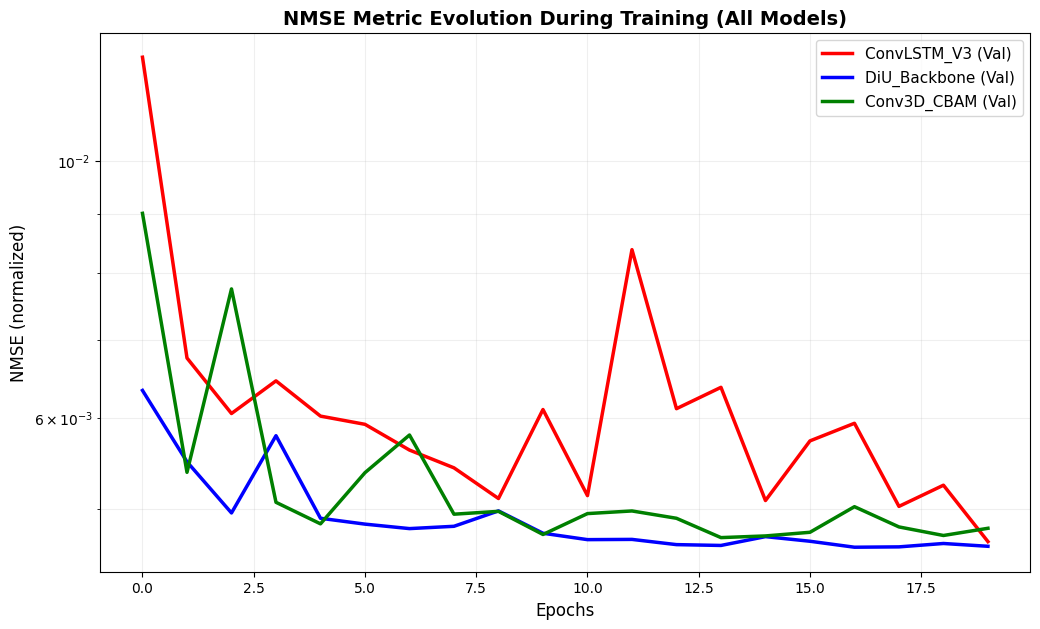

In [25]:
plt.figure(figsize=(12, 7))
colors = ['red', 'blue', 'green']

for idx, (name, hist) in enumerate(training_histories.items()):
    plt.plot(hist['val_nmse_metric'], label=f"{name} (Val)", color=colors[idx], linewidth=2.5)

plt.title('NMSE Metric Evolution During Training (All Models)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('NMSE (normalized)', fontsize=12)
plt.yscale('log') # Log scale is best to clearly see convergence separation
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## 5. Build Non-ML Baselines

In [13]:
# 1. Persistence Baseline (H_t)
pred_persistence_norm = X_test_scaled[:, -1, :, :, :]

from sklearn.linear_model import Ridge

# 2. Linear Regression Baseline 
print("Fitting Ridge Regression Benchmark...")
model = Ridge(alpha=1.0)

# Flatten temporal and spatial features per sample to maintain the network's mapping perspective
# X shape: (Samples, 10, 32, 32, 2) -> (Samples, 4480)
# Y shape: (Samples, 32, 32, 2) -> (Samples, 448)
X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
Y_train_flat = Y_train_scaled.reshape(Y_train_scaled.shape[0], -1)

# Fit the model on the training data
model.fit(X_train_flat, Y_train_flat)

# Generate predictions and reshape perfectly back to target shape
X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)
pred_regression_flat = model.predict(X_test_flat)
pred_regression_norm = pred_regression_flat.reshape(Y_test_scaled.shape)

predictions_norm["Baseline (Persistence)"] = pred_persistence_norm
predictions_norm["Baseline (Ridge Regression)"] = pred_regression_norm

Fitting Ridge Regression Benchmark...


/home/yhabie/project/NokiaCSIprediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.116718674955337e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


## 6. Comprehensive Evaluation Table
We measure physical absolute error via Denormalized metrics.

In [17]:
def evaluate_real_domain(pred_norm_data, name, tolerance=0.02):
    # Denormalize to get real magnitude values
    pred_real = (pred_norm_data * std) + mean
    
    # NMSE (dB) Calculation
    mse = np.sum(np.square(Y_test - pred_real), axis=(1, 2, 3))
    power = np.sum(np.square(Y_test), axis=(1, 2, 3)) + 1e-12
    # Round to 3 decimals
    nmse_db = round(np.mean(10.0 * np.log10(mse / power + 1e-12)), 3)
    
    # Similarity Calculation (Convert to integer percentage string)
    sim_val = np.mean(np.abs(Y_test - pred_real) < tolerance) * 100.0
    sim_str = f"{int(round(sim_val))}%"
    
    return {"Method": name, "Mean NMSE (dB)": nmse_db, f"Similarity (<{tolerance})": sim_str}

results = []
for name, p_data in predictions_norm.items():
    results.append(evaluate_real_domain(p_data, name, tolerance=0.02))

# Display Benchmark Table sorted by NMSE (Lower is Better -> So more negative is better)
df_benchmark = pd.DataFrame(results).sort_values(by="Mean NMSE (dB)", ascending=True).reset_index(drop=True)

# Ensure trailing zeros are shown for NMSE when displayed
df_benchmark["Mean NMSE (dB)"] = df_benchmark["Mean NMSE (dB)"].apply(lambda x: f"{x:.3f}")
display(df_benchmark)

,Method,Mean NMSE (dB),Similarity (<0.02)
0,DiU_Backbone,-28.452,68%
1,Conv3D_CBAM,-28.212,67%
2,ConvLSTM_V3,-28.181,67%
3,Baseline (Ridge Regression),-25.796,56%
4,Baseline (Persistence),-23.491,44%
5,Baseline (Linear Extrapol.),-18.950,27%


## 7. Visual Similarity Snapshot
Let's visually compare the amplitude of a random target state against the baselines and ML models.

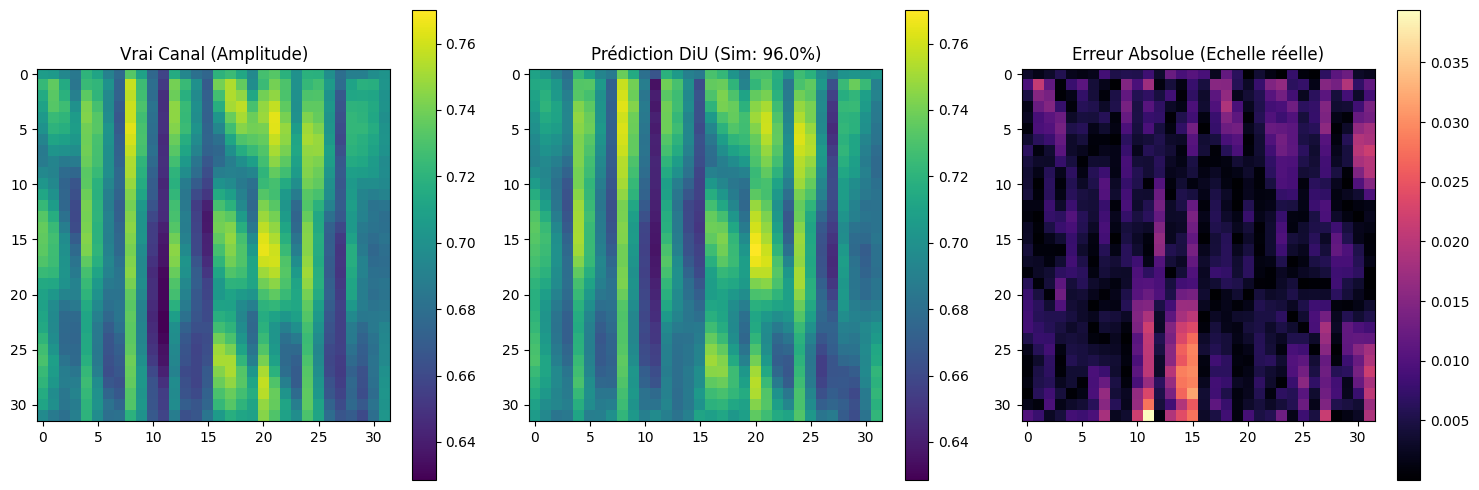

In [21]:
# Select a random snapshot
idx = 999

# Get True Target (Real Scale)
true_real = Y_test[idx]
true_amp = np.sqrt(true_real[..., 0]**2 + true_real[..., 1]**2)

# Get DiU_Backbone Prediction (Denormalized to Real Scale)
pred_norm = predictions_norm["DiU_Backbone"][idx]
pred_real = (pred_norm * std.squeeze()) + mean.squeeze()
pred_amp = np.sqrt(pred_real[..., 0]**2 + pred_real[..., 1]**2)

# Calculate similarity for THIS specific sample
tolerance = 0.02
sim_val = np.mean(np.abs(true_real - pred_real) < tolerance) * 100

v_min = min(true_amp.min(), pred_amp.min())
v_max = max(true_amp.max(), pred_amp.max())

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Vrai Canal (Amplitude)")
im1 = plt.imshow(true_amp, cmap='viridis', vmin=v_min, vmax=v_max)
plt.colorbar(im1)

plt.subplot(1, 3, 2)
plt.title(f"Prédiction DiU (Sim: {sim_val:.1f}%)")
im2 = plt.imshow(pred_amp, cmap='viridis', vmin=v_min, vmax=v_max)
plt.colorbar(im2)

plt.subplot(1, 3, 3)
plt.title("Erreur Absolue (Echelle réelle)")
im3 = plt.imshow(np.abs(true_amp - pred_amp), cmap='magma')
plt.colorbar(im3)

plt.tight_layout()
plt.show()